# Day 38 — Convolutional Neural Networks (CNNs)
### Convolutions · Pooling · CNN Architecture · Image Classification with PyTorch

## 1. Setup & Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")

print(f"PyTorch:     {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA:        {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:      {device}")
print("Ready! ✅")

PyTorch:     2.12.0+cpu
Torchvision: 0.27.0+cpu
CUDA:        False
Device:      cpu
Ready! ✅


## 2. What is a CNN?

In [2]:
print("=" * 55)
print("       WHAT IS A CNN?")
print("=" * 55)
print("""
PROBLEM WITH REGULAR NEURAL NETWORKS FOR IMAGES:
  A 32x32 colour image = 32 × 32 × 3 = 3,072 inputs
  A 224x224 image      = 224 × 224 × 3 = 150,528 inputs
  Fully connected layer → millions of parameters!
  Also loses spatial structure — pixels near each other matter!

CNN SOLUTION:
  Instead of connecting every pixel to every neuron,
  slide a small FILTER (kernel) across the image.
  The filter learns to detect patterns:
    Edge detector → spots edges
    Curve detector → spots curves
    Eye detector  → spots eyes (deeper layers)

CNN ARCHITECTURE:
  Input Image
    → CONV layer   (extract features with filters)
    → ReLU         (non-linearity)
    → POOL layer   (shrink spatial size)
    → CONV layer   (extract higher-level features)
    → ReLU + POOL
    → FLATTEN      (convert to 1D)
    → LINEAR       (classify)
    → OUTPUT       (class probabilities)

KEY ADVANTAGES OVER FULLY CONNECTED:
  ✅ Parameter sharing  — same filter scanned everywhere
  ✅ Local connectivity — each neuron sees small region
  ✅ Translation invariance — detects pattern anywhere
  ✅ Far fewer parameters — more efficient
""")

       WHAT IS A CNN?

PROBLEM WITH REGULAR NEURAL NETWORKS FOR IMAGES:
  A 32x32 colour image = 32 × 32 × 3 = 3,072 inputs
  A 224x224 image      = 224 × 224 × 3 = 150,528 inputs
  Fully connected layer → millions of parameters!
  Also loses spatial structure — pixels near each other matter!

CNN SOLUTION:
  Instead of connecting every pixel to every neuron,
  slide a small FILTER (kernel) across the image.
  The filter learns to detect patterns:
    Edge detector → spots edges
    Curve detector → spots curves
    Eye detector  → spots eyes (deeper layers)

CNN ARCHITECTURE:
  Input Image
    → CONV layer   (extract features with filters)
    → ReLU         (non-linearity)
    → POOL layer   (shrink spatial size)
    → CONV layer   (extract higher-level features)
    → ReLU + POOL
    → FLATTEN      (convert to 1D)
    → LINEAR       (classify)
    → OUTPUT       (class probabilities)

KEY ADVANTAGES OVER FULLY CONNECTED:
  ✅ Parameter sharing  — same filter scanned everywhere
  ✅ Lo

## 3. Load CIFAR-10 Dataset

       CIFAR-10 DATASET


100%|██████████| 170M/170M [00:06<00:00, 25.1MB/s] 


Training samples:   50000
Test samples:       10000
Classes:            ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image shape:        torch.Size([3, 32, 32])
Batches in train:   782


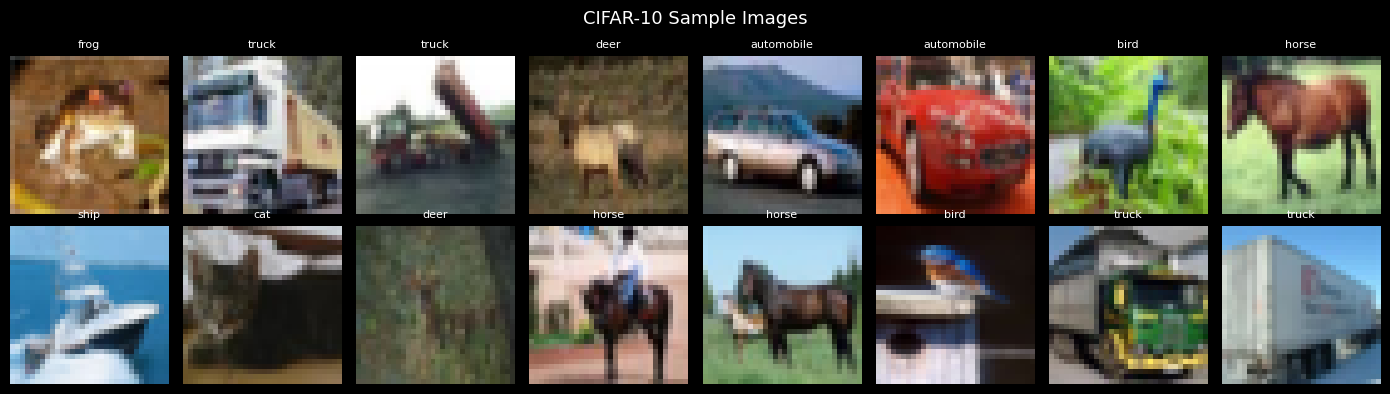

In [ ]:
print("=" * 55)
print("       CIFAR-10 DATASET")
print("=" * 55)

transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

# download dataset
train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

print(f"Training samples:   {len(train_dataset)}")
print(f"Test samples:       {len(test_dataset)}")
print(f"Classes:            {classes}")
print(f"Image shape:        {train_dataset[0][0].shape}")
print(f"Batches in train:   {len(train_loader)}")

# visualise some images
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle("CIFAR-10 Sample Images", fontsize=13)
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    img = img * 0.5 + 0.5  # unnormalise
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(classes[label], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Build the CNN

In [ ]:
print("=" * 55)
print("       BUILDING THE CNN")
print("=" * 55)


class CIFAR10Net(nn.Module):
    def __init__(self):
        super(CIFAR10Net, self).__init__()

        # BLOCK 1 — Conv → ReLU → Pool
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 channels in, 32 filters out
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32x32 → 16x16
        )

        # BLOCK 2 — Conv → ReLU → Pool
        self.block2 = nn.Sequential(
            nn.Conv2d(
                32, 64, kernel_size=3, padding=1
            ),  # 32 channels in, 64 filters out
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16x16 → 8x8
        )

        # BLOCK 3 — Conv → ReLU
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU()  # 64 → 128 filters
        )

        # CLASSIFIER — Flatten → Linear → Output
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10),  # 10 classes
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


model = CIFAR10Net().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

       BUILDING THE CNN
CIFAR10Net(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total parameters: 2,193,226


## 5. Train the CNN

       TRAINING THE CNN
Epoch  1/10 | Loss: 1.4450 | Val Acc: 60.2%
Epoch  2/10 | Loss: 1.0326 | Val Acc: 69.3%
Epoch  3/10 | Loss: 0.8544 | Val Acc: 72.2%
Epoch  4/10 | Loss: 0.7369 | Val Acc: 73.6%
Epoch  5/10 | Loss: 0.6383 | Val Acc: 74.6%
Epoch  6/10 | Loss: 0.4809 | Val Acc: 76.9%
Epoch  7/10 | Loss: 0.4244 | Val Acc: 77.0%
Epoch  8/10 | Loss: 0.3708 | Val Acc: 77.8%
Epoch  9/10 | Loss: 0.3226 | Val Acc: 77.1%
Epoch 10/10 | Loss: 0.2812 | Val Acc: 77.6%


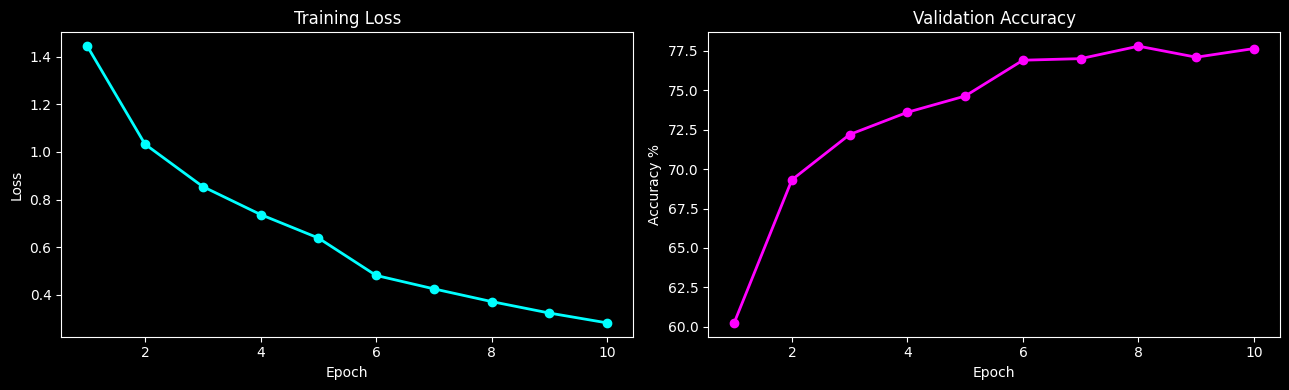

In [ ]:
print("=" * 55)
print("       TRAINING THE CNN")
print("=" * 55)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

epochs = 10
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    # ── TRAIN ──
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step()

    # ── EVALUATE ──
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total * 100
    val_accuracies.append(acc)
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {acc:.1f}%")

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(range(1, epochs + 1), train_losses, color="cyan", linewidth=2, marker="o")
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax2.plot(range(1, epochs + 1), val_accuracies, color="magenta", linewidth=2, marker="o")
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy %")
plt.tight_layout()
plt.show()

## 6. Per-Class Accuracy

       PER-CLASS ACCURACY
Class         Correct    Total   Accuracy
------------------------------------------
airplane          845     1000      84.5%
automobile        879     1000      87.9%
bird              679     1000      67.9%
cat               579     1000      57.9%
deer              714     1000      71.4%
dog               721     1000      72.1%
frog              821     1000      82.1%
horse             815     1000      81.5%
ship              862     1000      86.2%
truck             849     1000      84.9%


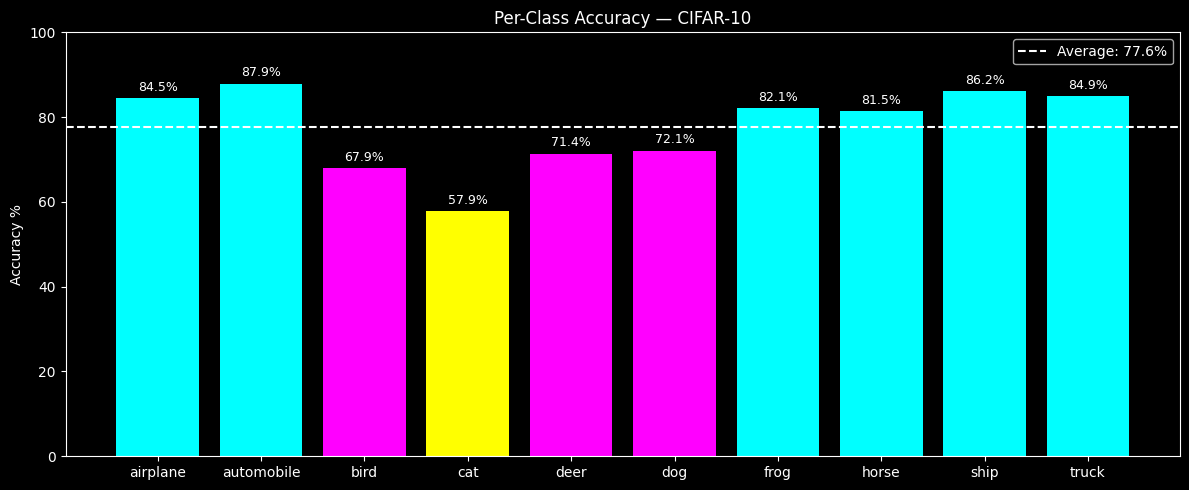

In [ ]:
print("=" * 55)
print("       PER-CLASS ACCURACY")
print("=" * 55)

model.eval()
class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == labels[i]).item()
            class_total[label] += 1

print(f"{'Class':<12} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 42)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:<12} {class_correct[i]:>8} {class_total[i]:>8} {acc:>9.1f}%")

# bar chart
accs = [100 * class_correct[i] / class_total[i] for i in range(10)]
colors = ["cyan" if a >= 75 else "magenta" if a >= 65 else "yellow" for a in accs]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(classes, accs, color=colors)
ax.axhline(
    y=sum(accs) / 10,
    color="white",
    linestyle="--",
    linewidth=1.5,
    label=f"Average: {sum(accs)/10:.1f}%",
)
ax.set_title("Per-Class Accuracy — CIFAR-10")
ax.set_ylabel("Accuracy %")
ax.set_ylim(0, 100)
ax.legend()
for bar, acc in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{acc:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

## 7. Key Takeaways

In [7]:
print("=" * 55)
print("       DAY 38 — KEY TAKEAWAYS")
print("=" * 55)
print("""
WHAT IS A CNN:
  ✅ Slides filters across image to detect patterns
  ✅ Parameter sharing — same filter used everywhere
  ✅ Preserves spatial structure unlike fully connected
  ✅ Translation invariant — finds pattern anywhere

CNN LAYERS:
  ✅ Conv2d   → applies filters, extracts features
  ✅ ReLU     → non-linearity after every conv
  ✅ MaxPool2d → shrinks spatial size, keeps strongest signal
  ✅ Flatten  → converts 3D feature map to 1D vector
  ✅ Linear   → final classification head

OUR CIFAR10NET:
  ✅ 3 conv blocks: 32 → 64 → 128 filters
  ✅ 2 MaxPool: 32x32 → 16x16 → 8x8
  ✅ 2,193,226 parameters
  ✅ 77.6% accuracy in just 10 epochs on CPU!

PER-CLASS INSIGHTS:
  ✅ Vehicles (auto, ship, truck) → easiest ~85-88%
  ✅ Animals (cat, bird) → hardest ~58-68%
  ✅ Similar-looking classes confuse the model

DATASET:
  ✅ CIFAR-10 — 60,000 images, 10 classes, 32x32
  ✅ CrossEntropyLoss for multi-class classification
  ✅ DataLoader handles batching automatically
""")

       DAY 38 — KEY TAKEAWAYS

WHAT IS A CNN:
  ✅ Slides filters across image to detect patterns
  ✅ Parameter sharing — same filter used everywhere
  ✅ Preserves spatial structure unlike fully connected
  ✅ Translation invariant — finds pattern anywhere

CNN LAYERS:
  ✅ Conv2d   → applies filters, extracts features
  ✅ ReLU     → non-linearity after every conv
  ✅ MaxPool2d → shrinks spatial size, keeps strongest signal
  ✅ Flatten  → converts 3D feature map to 1D vector
  ✅ Linear   → final classification head

OUR CIFAR10NET:
  ✅ 3 conv blocks: 32 → 64 → 128 filters
  ✅ 2 MaxPool: 32x32 → 16x16 → 8x8
  ✅ 2,193,226 parameters
  ✅ 77.6% accuracy in just 10 epochs on CPU!

PER-CLASS INSIGHTS:
  ✅ Vehicles (auto, ship, truck) → easiest ~85-88%
  ✅ Animals (cat, bird) → hardest ~58-68%
  ✅ Similar-looking classes confuse the model

DATASET:
  ✅ CIFAR-10 — 60,000 images, 10 classes, 32x32
  ✅ CrossEntropyLoss for multi-class classification
  ✅ DataLoader handles batching automatically

